## Задания для практических занятий и самостоятельной работы к главе 2


## Вариант 13

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import root_scalar

### Задание 1

Графический метод
Уравнение: 5·sin(2x) = √(1-x)


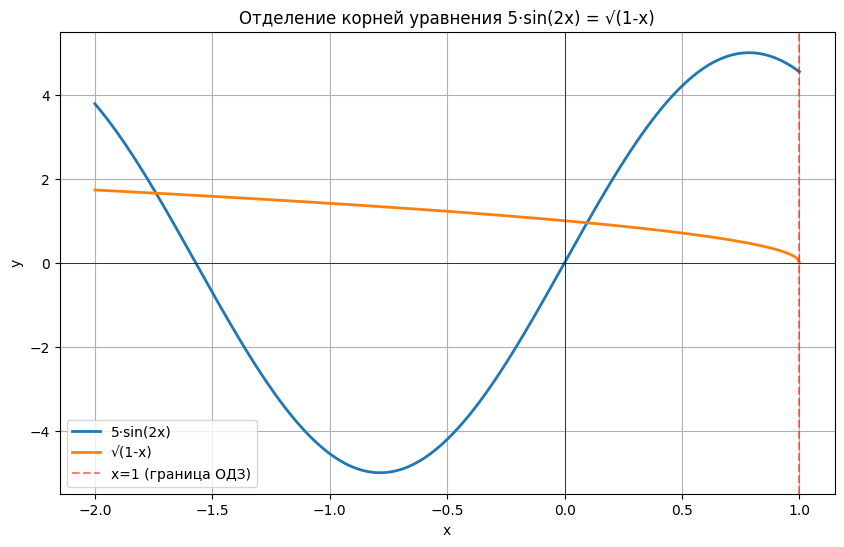


Интервалы, содержащие корни:
----------------------------------------
Корень на [-1.74; -1.74]
Корень на [0.09; 0.10]


In [2]:
print("Графический метод")
print("Уравнение: 5·sin(2x) = √(1-x)")

# Область определения: 1-x ≥ 0 → x ≤ 1
x = np.linspace(-2, 1, 500)  # рассматриваем от -2 до 1

y1 = 5 * np.sin(2 * x)        # левая часть
y2 = np.sqrt(1 - x)           # правая часть (корень определен только при x ≤ 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='5·sin(2x)', linewidth=2)
plt.plot(x, y2, label='√(1-x)', linewidth=2)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения 5·sin(2x) = √(1-x)')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.axvline(1, color='red', linestyle='--', alpha=0.5, label='x=1 (граница ОДЗ)')
plt.legend()
plt.show()

# Находим интервалы, где функции пересекаются
print("\nИнтервалы, содержащие корни:")
print("-" * 40)
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на [{x[i]:.2f}; {x[i+1]:.2f}]")

### Задание 2

In [3]:
print("Метод половинного деления")
def f(x):
    return 5 * math.sin(2 * x) - math.sqrt(1 - x)

a, b, eps = 0.2, 0.8, 0.001

while b - a > eps:
    c = (a + b) / 2
    if f(a) * f(c) <= 0:
        b = c
    else:
        a = c

print(f"Корень: {(a + b) / 2:.6f}")

Метод половинного деления
Корень: 0.799707


### Задание 3

In [4]:
print("Метод простой итерации")
def f(x):
    return 5 * math.sin(2 * x) - math.sqrt(1 - x)

def phi(x):
    return 1 - (5 * math.sin(2 * x))**2

x0, eps = 0.5, 1e-6

while True:
    x1 = phi(x0)
    if abs(x1 - x0) < eps:
        break
    x0 = x1

print(f"Корень: {x1:.6f}")

Метод простой итерации
Корень: -22.659716


### Задание 4

Уравнение: 5·sin(2x) = √(1-x)
Интервал: [0.0, 0.5], точность: 1e-06
------------------------------------------------------------
Итерация   x (середина)    f(x)            |x_i - x_i-1|  
------------------------------------------------------------
1          0.01912256      -0.79921357     0.23087744     
2          0.01782576      -0.81282725     0.00129681     
3          0.01791739      -0.81186525     0.00009164     
4          0.01791093      -0.81193304     0.00000646     
5          0.01791139      -0.81192827     0.00000046     
------------------------------------------------------------
КОРЕНЬ: x = 0.01791139
Количество итераций: 5
Значение функции: f(x) = -8.12e-01

РЕЗУЛЬТАТ:
  Корень уравнения: x = 0.01791139
  Проверка: 5·sin(2x) = 0.17907557
            √(1-x)    = 0.99100384
  Разность: -8.12e-01


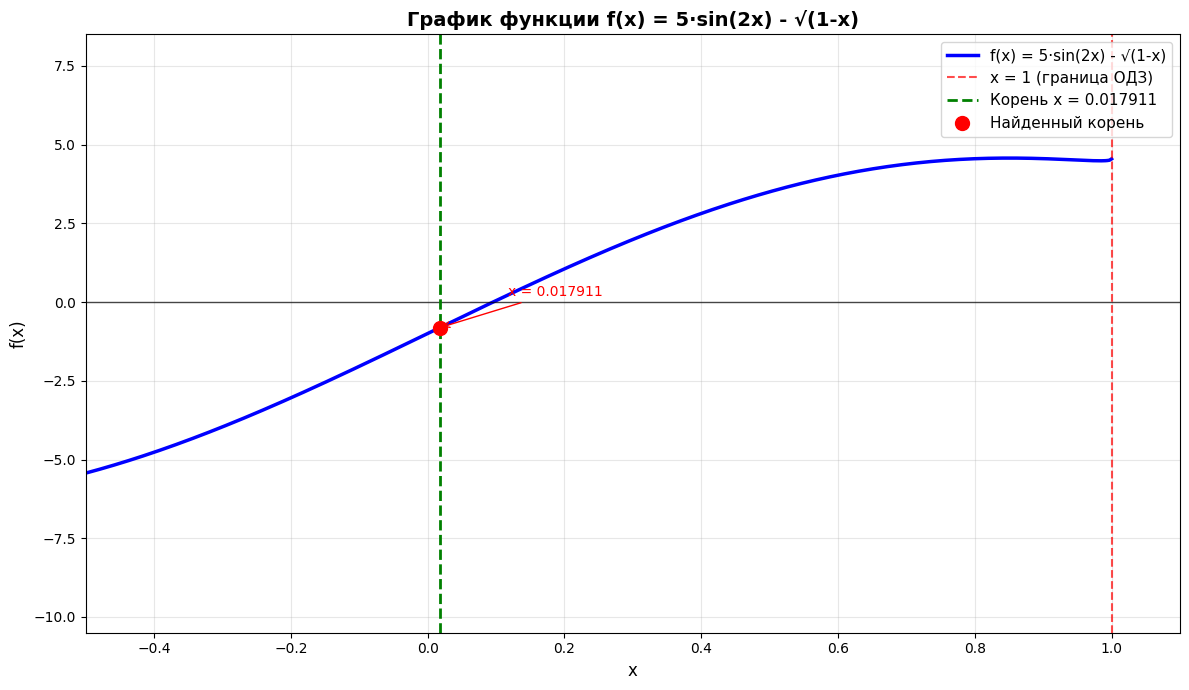

In [5]:
# Определяем функцию и её производную
def f(x):
    """f(x) = 5*sin(2x) - sqrt(1-x)"""
    if x > 1:
        return float('nan')  # Вне области определения
    return 5 * math.sin(2*x) - math.sqrt(1 - x)

def f_prime(x):
    """Производная: f'(x) = 10*cos(2x) + 1/(2*sqrt(1-x))"""
    if x >= 1:
        return float('inf')  # Производная стремится к бесконечности
    return 10 * math.cos(2*x) + 1/(2 * math.sqrt(1 - x))

# Комбинированный метод хорд и касательных
def find_root(a, b, eps=1e-6, max_iter=50):
    """
    Находит корень уравнения f(x)=0 на отрезке [a, b]
    комбинированным методом хорд и касательных
    """
    print(f"Уравнение: 5·sin(2x) = √(1-x)")
    print(f"Интервал: [{a}, {b}], точность: {eps}")
    print("-" * 60)
    print(f"{'Итерация':<10} {'x (середина)':<15} {'f(x)':<15} {'|x_i - x_i-1|':<15}")
    print("-" * 60)
    
    x_prev = (a + b) / 2  # Начальное приближение
    
    for i in range(max_iter):
        # Метод хорд (секущих)
        # Формула: x_chord = a - f(a)*(b-a)/(f(b)-f(a))
        if abs(f(b) - f(a)) < 1e-12:
            print("Ошибка: разность значений функции слишком мала")
            return None, i
        x_chord = a - f(a) * (b - a) / (f(b) - f(a))
        
        # Метод касательных (Ньютона)
        # Выбираем, из какой точки проводить касательную
        if f(a) * f_prime(a) > 0:
            # Касательная из точки a
            if abs(f_prime(a)) < 1e-12:
                print("Производная близка к нулю в точке a")
                return None, i
            x_tangent = a - f(a) / f_prime(a)
        else:
            # Касательная из точки b
            if abs(f_prime(b)) < 1e-12:
                print("Производная близка к нулю в точке b")
                return None, i
            x_tangent = b - f(b) / f_prime(b)
        
        # Комбинированный метод - берём среднее
        x = (x_chord + x_tangent) / 2
        
        # Проверка сходимости
        diff = abs(x - x_prev)
        print(f"{i+1:<10} {x:<15.8f} {f(x):<15.8f} {diff:<15.8f}")
        
        # Критерий остановки
        if abs(f(x)) < eps or diff < eps:
            print("-" * 60)
            print(f"КОРЕНЬ: x = {x:.8f}")
            print(f"Количество итераций: {i+1}")
            print(f"Значение функции: f(x) = {f(x):.2e}")
            return x, i+1
        
        # Сужаем интервал
        if f(a) * f(x) < 0:
            b = x  # Корень между a и x
        else:
            a = x  # Корень между x и b
        
        x_prev = x
    
    print("-" * 60)
    print(f"Достигнуто максимальное число итераций ({max_iter})")
    return (a + b) / 2, max_iter

# Основная программа
if __name__ == "__main__":
    # Находим корень на интервале [0, 0.5]
    # Проверка: f(0) = -1 < 0, f(0.5) ≈ 3.5 > 0
    a, b = 0.0, 0.5
    
    # Вычисляем корень
    root, iterations = find_root(a, b, eps=1e-6)
    
    if root is not None:
        print(f"\nРЕЗУЛЬТАТ:")
        print(f"  Корень уравнения: x = {root:.8f}")
        print(f"  Проверка: 5·sin(2x) = {5 * math.sin(2*root):.8f}")
        print(f"            √(1-x)    = {math.sqrt(1 - root):.8f}")
        print(f"  Разность: {f(root):.2e}")
    
    # Создаем массив точек для графика
    x_vals = np.linspace(-0.5, 1.0, 500)
    y_vals = []
    
    for xi in x_vals:
        if xi <= 1:
            y_vals.append(5 * np.sin(2*xi) - np.sqrt(1 - xi))
        else:
            y_vals.append(np.nan)
    
    # Построение графика
    plt.figure(figsize=(12, 7))
    
    # График функции
    plt.plot(x_vals, y_vals, 'b-', linewidth=2.5, 
             label='f(x) = 5·sin(2x) - √(1-x)')
    
    # Нулевая линия
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    
    # Вертикальная линия - граница ОДЗ
    plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label='x = 1 (граница ОДЗ)')
    
    # Найденный корень
    if root is not None:
        plt.axvline(x=root, color='green', linestyle='--', linewidth=2,
                    label=f'Корень x = {root:.6f}')
        plt.plot(root, f(root), 'ro', markersize=10, 
                label='Найденный корень')
        
        # Аннотация
        plt.annotate(f'x = {root:.6f}', 
                    xy=(root, f(root)), 
                    xytext=(root+0.1, f(root)+1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10,
                    color='red')
    
    # Настройки графика
    plt.grid(True, alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.title('График функции f(x) = 5·sin(2x) - √(1-x)', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='upper right')
    plt.xlim(-0.5, 1.1)
    
    # Вычисляем пределы по y
    y_min = -10
    y_max = 8
    for yi in y_vals:
        if not np.isnan(yi) and -20 < yi < 20:
            y_min = min(y_min, yi)
            y_max = max(y_max, yi)
    plt.ylim(y_min - 0.5, y_max + 0.5)
    
    plt.tight_layout()
    plt.show()

### Задание 5

Уравнение: 5·sin(2x) = √(1-x)
Интервал: [0.0, 0.5], точность: 1e-06

Метод: brentq
Корень найден: x = 0.09567849
Значение функции: f(x) = -1.75e-06
Количество итераций: 5
Сходимость: converged
РЕЗУЛЬТАТ:
  Корень уравнения: x = 0.09567849
  Проверка: 5·sin(2x) = 0.95095645
            √(1-x)    = 0.95095820
  Разность: -1.75e-06


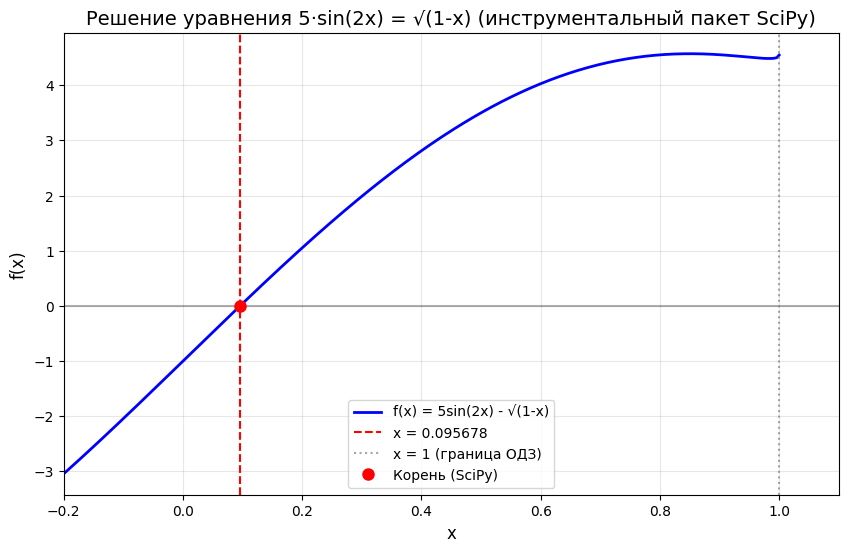

In [6]:


def f(x): 
    if x > 1: return float('nan')
    return 5*math.sin(2*x) - math.sqrt(1-x)

# Задание 5: Инструментальный пакет (SciPy)
def solve_with_scipy(a, b, eps=1e-6):
    print(f"Уравнение: 5·sin(2x) = √(1-x)")
    print(f"Интервал: [{a}, {b}], точность: {eps}\n")
    
    # Используем метод Брента (комбинация методов)
    sol = root_scalar(f, bracket=[a, b], method='brentq', xtol=eps, rtol=eps)
    
    if sol.converged:
        print(f"Метод: {sol.method}")
        print(f"Корень найден: x = {sol.root:.8f}")
        # Проверяем доступные атрибуты
        if hasattr(sol, 'function_value'):
            print(f"Значение функции: f(x) = {sol.function_value:.2e}")
        elif hasattr(sol, 'f'):
            print(f"Значение функции: f(x) = {sol.f:.2e}")
        else:
            # Вычисляем значение функции сами
            print(f"Значение функции: f(x) = {f(sol.root):.2e}")
        
        if hasattr(sol, 'iterations'):
            print(f"Количество итераций: {sol.iterations}")
        else:
            print("Количество итераций: не указано")
            
        print(f"Сходимость: {sol.flag}")
        return sol.root, getattr(sol, 'iterations', 0)
    else:
        print("Решение не сошлось")
        return None, 0

# Интервал для поиска корня
interval_start = 0.0
interval_end = 0.5
eps = 1e-6

# Вычисление корня с помощью SciPy
root, iterations = solve_with_scipy(interval_start, interval_end, eps)

if root is not None:
    print("РЕЗУЛЬТАТ:")
    print(f"  Корень уравнения: x = {root:.8f}")
    print(f"  Проверка: 5·sin(2x) = {5*math.sin(2*root):.8f}")
    print(f"            √(1-x)    = {math.sqrt(1-root):.8f}")
    print(f"  Разность: {f(root):.2e}")

# Построение графика
x_vals = np.linspace(-0.2, 1.0, 300)
y_vals = [5*np.sin(2*xi) - np.sqrt(1-xi) if xi <= 1 else float('nan') for xi in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = 5sin(2x) - √(1-x)')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=root, color='r', linestyle='--', label=f'x = {root:.6f}')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7, label='x = 1 (граница ОДЗ)')
plt.plot(root, f(root), 'ro', markersize=8, label='Корень (SciPy)')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Решение уравнения 5·sin(2x) = √(1-x) (инструментальный пакет SciPy)', fontsize=14)
plt.legend(fontsize=10)
plt.xlim(-0.2, 1.1)
plt.show()